# Лабораторная работа №4: Генерация данных с использованием вариационных автоэнкодеров (VAE)

Выполнила Гареева Д.Р 507540

In [ ]:
# !pip list

## Шаг 1: Подготовка данных

2026-05-02 18:41:52.417014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777747312.439221    2700 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777747312.446544    2700 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777747312.465065    2700 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777747312.465085    2700 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777747312.465088    2700 computation_placer.cc:177] computation placer alr

Форма тренировочных данных: (60000, 28, 28, 1)
Форма тестовых данных: (10000, 28, 28, 1)
Размер тренировочного набора: (60000, 28, 28, 1), метки: (60000,)
Размер тестового набора: (10000, 28, 28, 1), метки: (10000,)


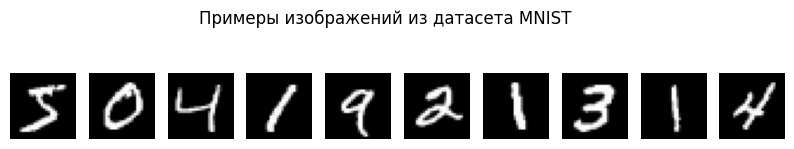

Распределение классов в тренировочном наборе: {np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}
Распределение классов в тестовом наборе: {np.uint8(0): np.int64(980), np.uint8(1): np.int64(1135), np.uint8(2): np.int64(1032), np.uint8(3): np.int64(1010), np.uint8(4): np.int64(982), np.uint8(5): np.int64(892), np.uint8(6): np.int64(958), np.uint8(7): np.int64(1028), np.uint8(8): np.int64(974), np.uint8(9): np.int64(1009)}


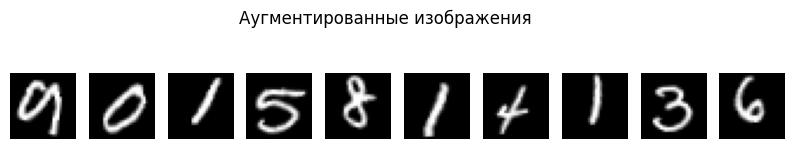

Размер после преобразования: (60000, 784)
Минимум: 0.0000, Максимум: 1.0000
Среднее: 0.1307, Стандартное отклонение: 0.3081


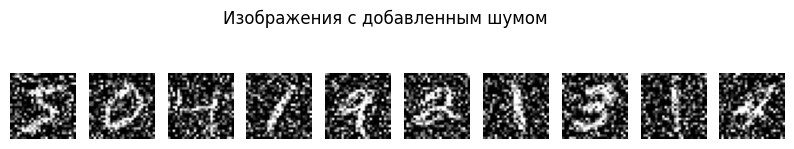

Размер небольшого поднабора: (1000, 28, 28, 1)


In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Lambda, Layer
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
import warnings
warnings.filterwarnings('ignore')

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"Форма тренировочных данных: {x_train.shape}")
print(f"Форма тестовых данных: {x_test.shape}")

print(f"Размер тренировочного набора: {x_train.shape}, метки: {y_train.shape}")
print(f"Размер тестового набора: {x_test.shape}, метки: {y_test.shape}")

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Примеры изображений из датасета MNIST")
plt.show()

unique, counts = np.unique(y_train, return_counts=True)
print(f"Распределение классов в тренировочном наборе: {dict(zip(unique, counts))}")
unique, counts = np.unique(y_test, return_counts=True)
print(f"Распределение классов в тестовом наборе: {dict(zip(unique, counts))}")

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(x_train)

augmented_images, _ = next(datagen.flow(x_train, y_train, batch_size=10))
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(augmented_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Аугментированные изображения")
plt.show()

x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)
print(f"Размер после преобразования: {x_train_flat.shape}")

print(f"Минимум: {x_train.min():.4f}, Максимум: {x_train.max():.4f}")
print(f"Среднее: {x_train.mean():.4f}, Стандартное отклонение: {x_train.std():.4f}")

noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Изображения с добавленным шумом")
plt.show()

small_x_train = x_train[:1000]
small_y_train = y_train[:1000]
print(f"Размер небольшого поднабора: {small_x_train.shape}")

## Шаг 2: Реализация автокодировщика (AE)

Обучение классического автокодировщика (AE)


I0000 00:00:1777747384.755958    2700 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777747384.757900    2700 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


I0000 00:00:1777747387.050706    2803 service.cc:152] XLA service 0x7cea3d00c990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777747387.050741    2803 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777747387.050745    2803 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777747387.182982    2803 cuda_dnn.cc:529] Loaded cuDNN version 91002


 66/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4982

I0000 00:00:1777747387.833639    2803 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3593 - val_loss: 0.1681
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1583 - val_loss: 0.1333
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1286 - val_loss: 0.1147
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1117 - val_loss: 0.1030
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1006 - val_loss: 0.0951
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0932 - val_loss: 0.0893
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0877 - val_loss: 0.0852
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0837 - val_loss: 0.0823
Epoch 9/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0812 - val_loss: 0.0803
Epoch 10/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0792 - val_loss: 0.0789


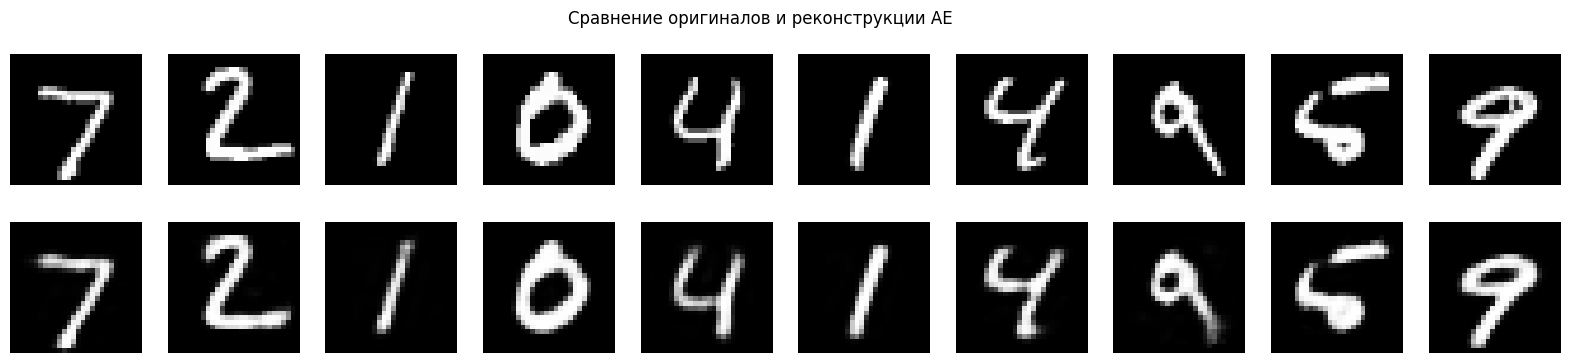

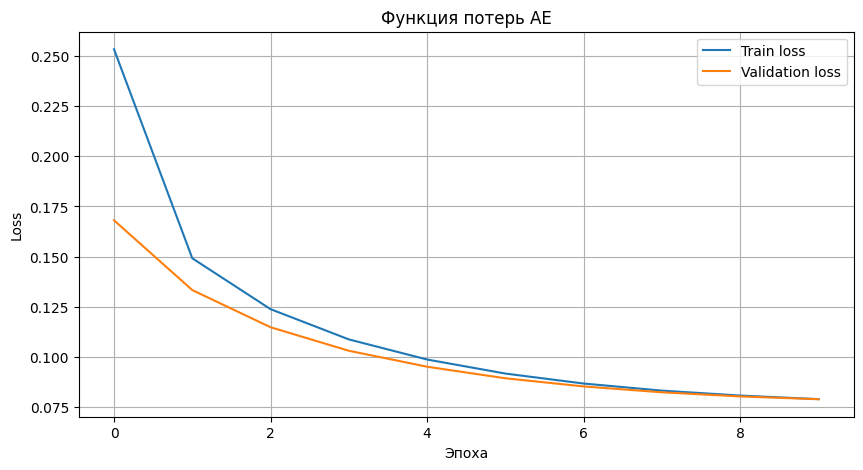

In [3]:
print("Обучение классического автокодировщика (AE)")

input_img = Input(shape=(28, 28, 1))
x = Flatten()(input_img)
encoded = Dense(64, activation='relu', name='bottleneck')(x)
decoded = Dense(28 * 28, activation='sigmoid')(encoded)
decoded = Reshape((28, 28, 1))(decoded)


autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


history_ae = autoencoder.fit(x_train, x_train, 
                             epochs=10, 
                             batch_size=256, 
                             validation_split=0.1,
                             verbose=1)


n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("Оригинал", fontsize=12)
    

    plt.subplot(2, n, n + i + 1)
    reconstructed = autoencoder.predict(x_test[i:i+1], verbose=0)
    plt.imshow(reconstructed.reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("Реконструкция AE", fontsize=12)
plt.suptitle("Сравнение оригиналов и реконструкции AE")
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(history_ae.history['loss'], label='Train loss')
plt.plot(history_ae.history['val_loss'], label='Validation loss')
plt.title('Функция потерь AE')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

## Шаг 3: Реализация вариационного автокодировщика (VAE)

Обучение вариационного автокодировщика (VAE)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 784)       │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │    200,960 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     32,896 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 28, 28, 1) │    234,896 │ lambda_1[0][0]    │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_loss_layer_1    │ (None, 28, 28, 1) │          0 │ input_layer_5[0]… │
│ (VAELossLayer)      │                   │            │ decoder[0][0],    │
│                     │                   │            │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 469,268 (1.79 MB)

 Trainable params: 469,268 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 70184.2109 - val_loss: 45407.5039
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 45258.3398 - val_loss: 43025.6602
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 43528.7969 - val_loss: 42036.9219
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 42598.0820 - val_loss: 41131.3086
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 41639.1953 - val_loss: 40348.0430
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 40905.7578 - val_loss: 39747.7773
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 40326.2656 - val_loss: 39408.6133
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 39908.8594 - val_loss: 39096.9023
Epoch 9/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 39609.0234 - val_loss: 38847.5391
Epoch 10/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 39265.7969 - val_loss: 38713.7188
Epoch 11/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - los

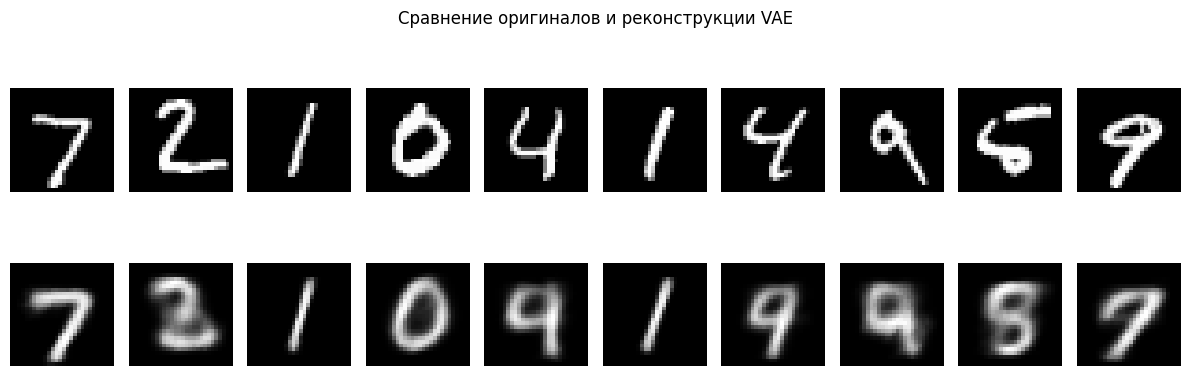

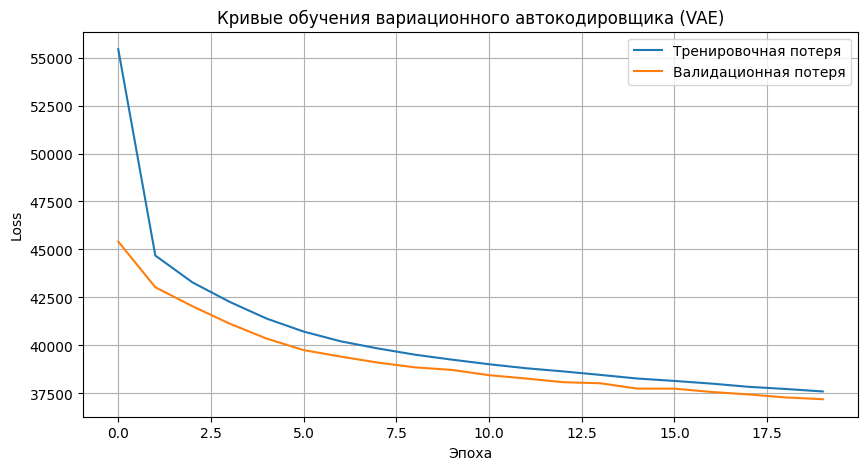

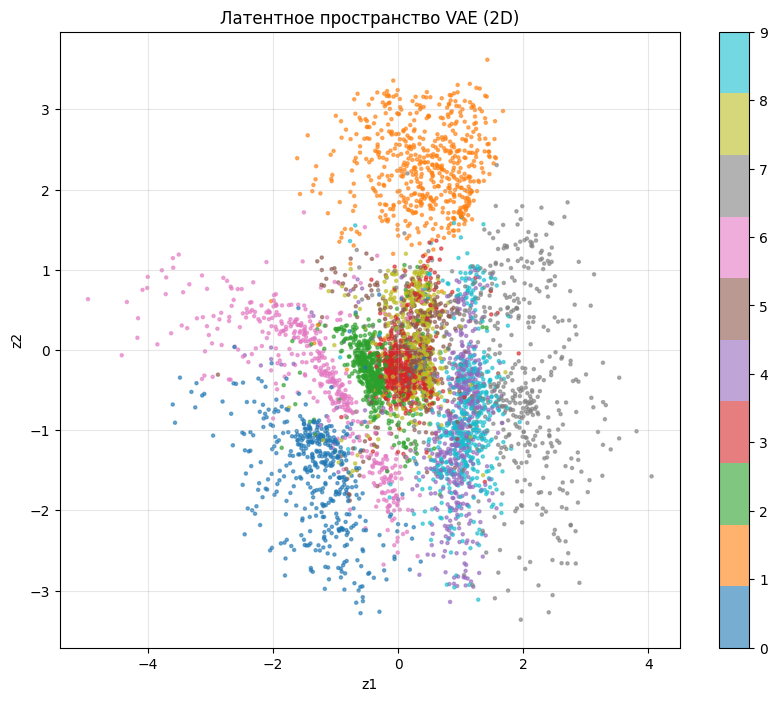

In [7]:
print("Обучение вариационного автокодировщика (VAE)")


latent_dim = 2

class VAELossLayer(Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)
        
    def call(self, inputs):
        input_img, output, z_mean, z_log_var = inputs
        
        reconstruction_loss = K.sum(K.binary_crossentropy(
            K.flatten(input_img), 
            K.flatten(output)
        ))
        
        kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var))
        
        self.add_loss(reconstruction_loss + kl_loss)
        
        return output

input_img = Input(shape=(28, 28, 1))
x = Flatten()(input_img)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=K.shape(z_mean))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_log_var])

decoder_input = Input(shape=(latent_dim,))
decoder_h = Dense(128, activation='relu')(decoder_input)
decoder_h = Dense(256, activation='relu')(decoder_h)
decoder_output = Dense(28 * 28, activation='sigmoid')(decoder_h)
decoder_output = Reshape((28, 28, 1))(decoder_output)
decoder = Model(decoder_input, decoder_output, name='decoder')

decoded = decoder(z)

output = VAELossLayer()([input_img, decoded, z_mean, z_log_var])
vae = Model(input_img, output)
vae.compile(optimizer='adam')
vae.summary()

# Обучение VAE
history_vae = vae.fit(x_train, x_train,
                      epochs=20,
                      batch_size=256,
                      validation_split=0.1,
                      verbose=1)

x_test_reconstructed_vae = vae.predict(x_test)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Оригинал', fontsize=12)
    
    plt.subplot(3, 10, 10 + i + 1)
    plt.imshow(x_test_reconstructed_vae[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Реконструкция VAE', fontsize=12)

plt.suptitle("Сравнение оригиналов и реконструкции VAE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_vae.history['loss'], label='Тренировочная потеря')
if 'val_loss' in history_vae.history:
    plt.plot(history_vae.history['val_loss'], label='Валидационная потеря')
plt.title('Кривые обучения вариационного автокодировщика (VAE)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

encoder_model = Model(input_img, z_mean)
z_points = encoder_model.predict(x_test[:5000], verbose=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_points[:, 0], z_points[:, 1], c=y_test[:5000], cmap='tab10', s=5, alpha=0.6)
plt.colorbar(scatter)
plt.title('Латентное пространство VAE (2D)')
plt.xlabel('z1')
plt.ylabel('z2')
plt.grid(True, alpha=0.3)
plt.show()


## Шаг 4: Сравнение PCA, AE и VAE

Сравнение PCA, AE и VAE


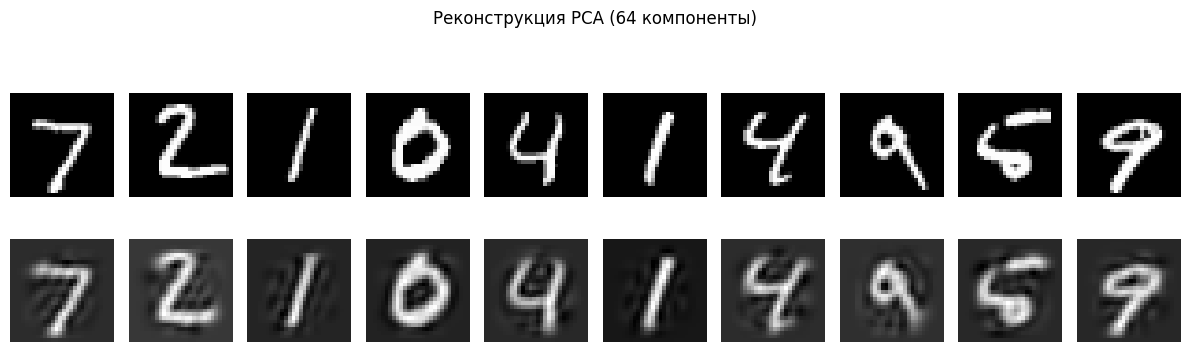

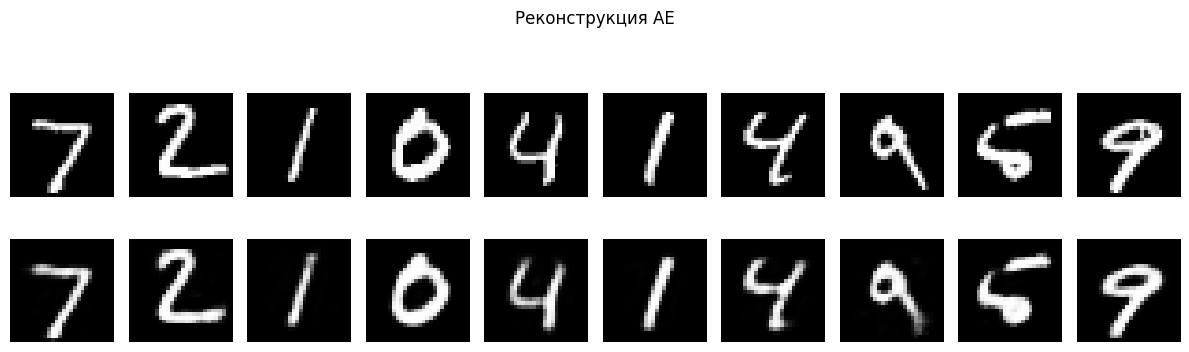

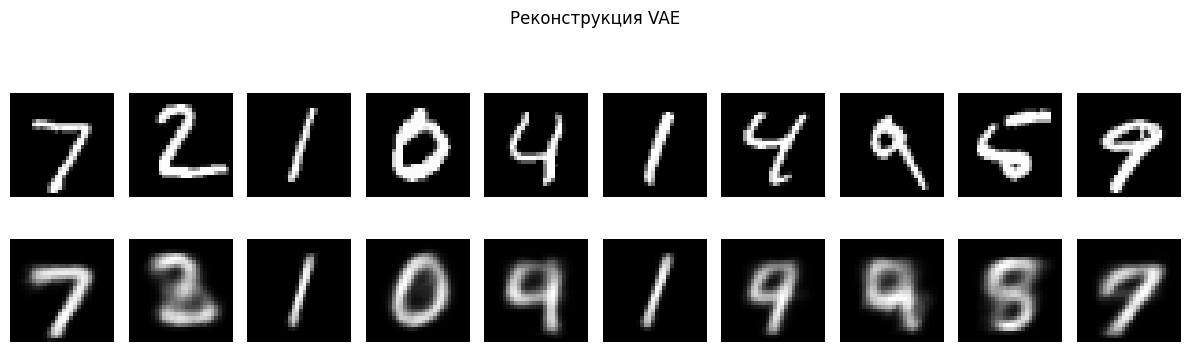

MSE для PCA: 0.009047
MSE для AE: 0.005117
MSE для VAE: 0.040191


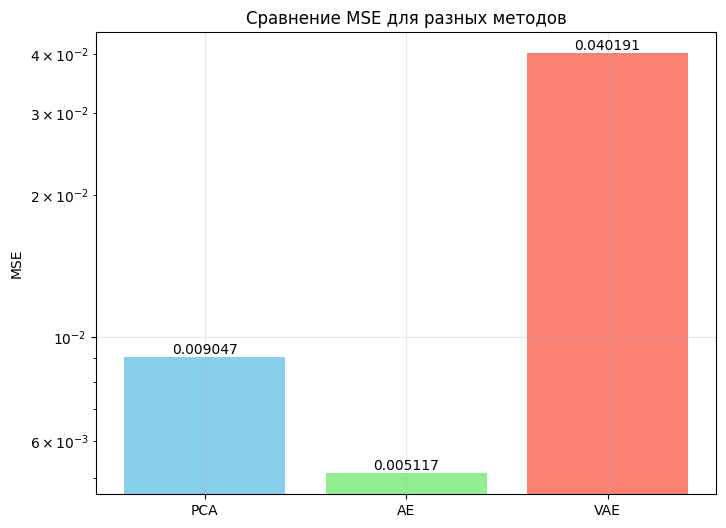

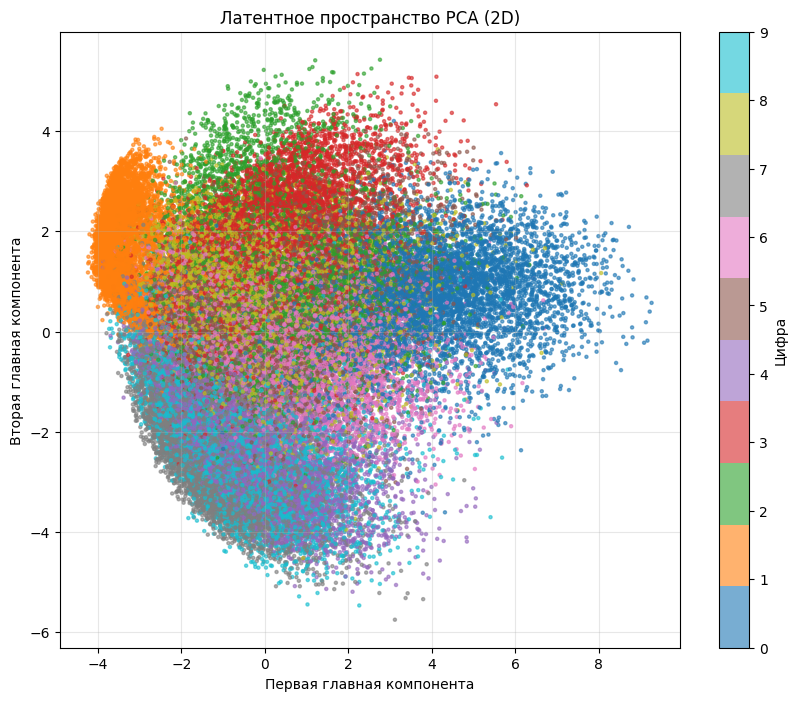

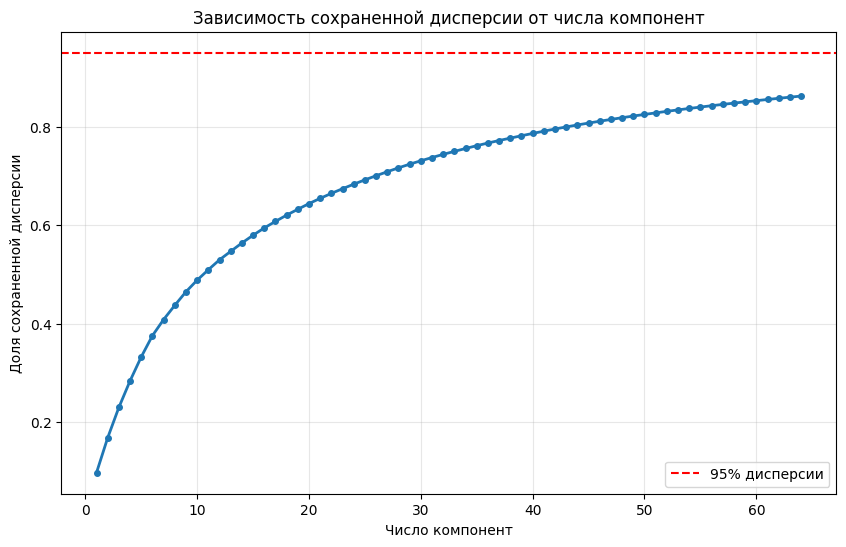

Для сохранения 90% дисперсии нужно 1 компонент
Для сохранения 95% дисперсии нужно 1 компонент


In [8]:
print("Сравнение PCA, AE и VAE")


pca = PCA(n_components=64)
x_train_pca = pca.fit_transform(x_train_flat)
x_test_pca = pca.transform(x_test_flat)
x_test_reconstructed_pca = pca.inverse_transform(x_test_pca)


def visualize_reconstruction(original, reconstructed, title, num_images=10):
    plt.figure(figsize=(12, 4))
    for i in range(num_images):
        plt.subplot(2, num_images, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.ylabel('Оригинал', fontsize=12)
        
        plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.ylabel('Реконструкция', fontsize=12)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


visualize_reconstruction(x_test, x_test_reconstructed_pca, "Реконструкция PCA (64 компоненты)")
visualize_reconstruction(x_test, x_test_reconstructed_ae, "Реконструкция AE")
visualize_reconstruction(x_test, x_test_reconstructed_vae, "Реконструкция VAE")


mse_pca = mean_squared_error(x_test_flat, x_test_reconstructed_pca)
mse_ae = mean_squared_error(x_test_flat, x_test_reconstructed_ae.reshape(len(x_test_reconstructed_ae), -1))
mse_vae = mean_squared_error(x_test_flat, x_test_reconstructed_vae.reshape(len(x_test_reconstructed_vae), -1))

print(f"MSE для PCA: {mse_pca:.6f}")
print(f"MSE для AE: {mse_ae:.6f}")
print(f"MSE для VAE: {mse_vae:.6f}")

methods = ['PCA', 'AE', 'VAE']
mse_values = [mse_pca, mse_ae, mse_vae]

plt.figure(figsize=(8, 6))
plt.bar(methods, mse_values, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Сравнение MSE для разных методов')
plt.ylabel('MSE')
plt.yscale('log')
for i, v in enumerate(mse_values):
    plt.text(i, v, f'{v:.6f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)
plt.show()


pca_2d = PCA(n_components=2)
x_train_pca_2d = pca_2d.fit_transform(x_train_flat)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x_train_pca_2d[:, 0], x_train_pca_2d[:, 1], c=y_train, cmap='tab10', s=5, alpha=0.6)
plt.colorbar(scatter, label='Цифра')
plt.title('Латентное пространство PCA (2D)')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.grid(True, alpha=0.3)
plt.show()


explained_variance = []
components_range = range(1, 65)
for n in components_range:
    pca_temp = PCA(n_components=n)
    pca_temp.fit(x_train_flat)
    explained_variance.append(sum(pca_temp.explained_variance_ratio_))

plt.figure(figsize=(10, 6))
plt.plot(components_range, explained_variance, marker='o', linewidth=2, markersize=4)
plt.title('Зависимость сохраненной дисперсии от числа компонент')
plt.xlabel('Число компонент')
plt.ylabel('Доля сохраненной дисперсии')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.legend()
plt.show()

print(f"Для сохранения 90% дисперсии нужно {np.argmax(np.array(explained_variance) >= 0.9) + 1} компонент")
print(f"Для сохранения 95% дисперсии нужно {np.argmax(np.array(explained_variance) >= 0.95) + 1} компонент")

## Шаг 5: Генерация данных

Генерация данных с помощью VAE


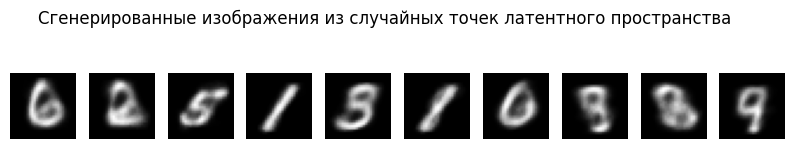

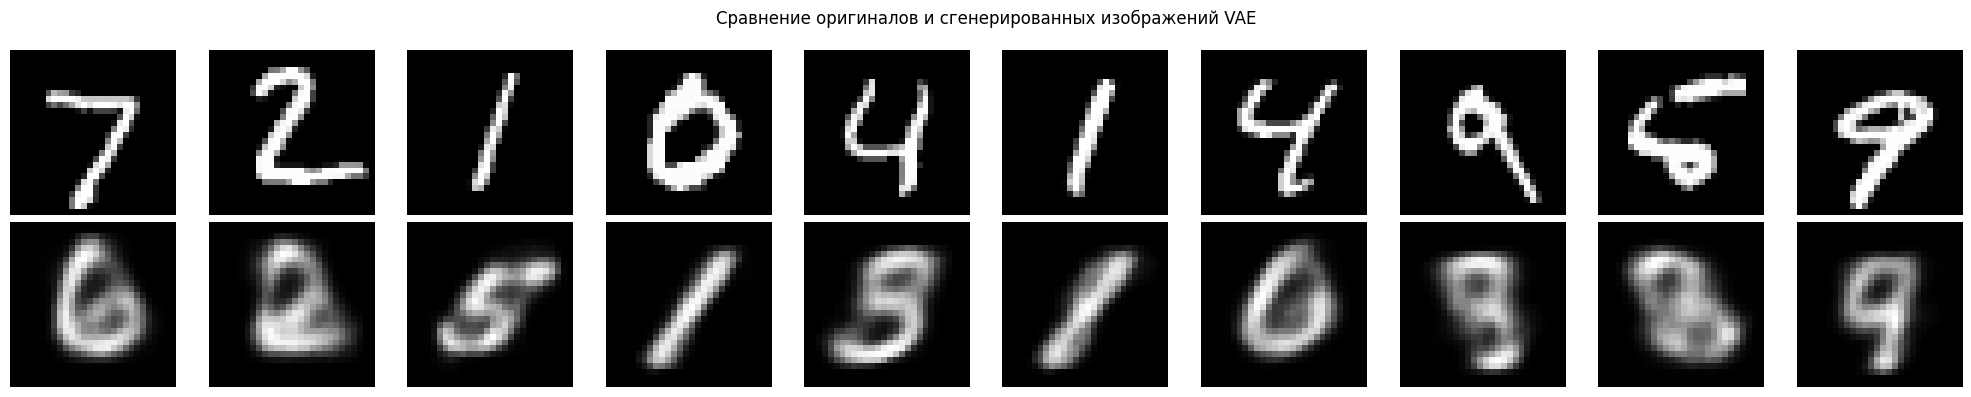

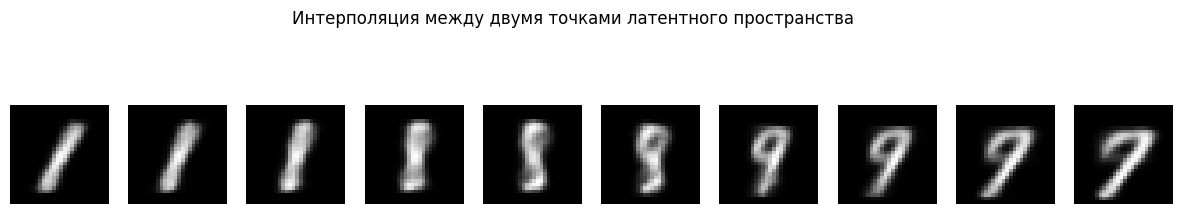

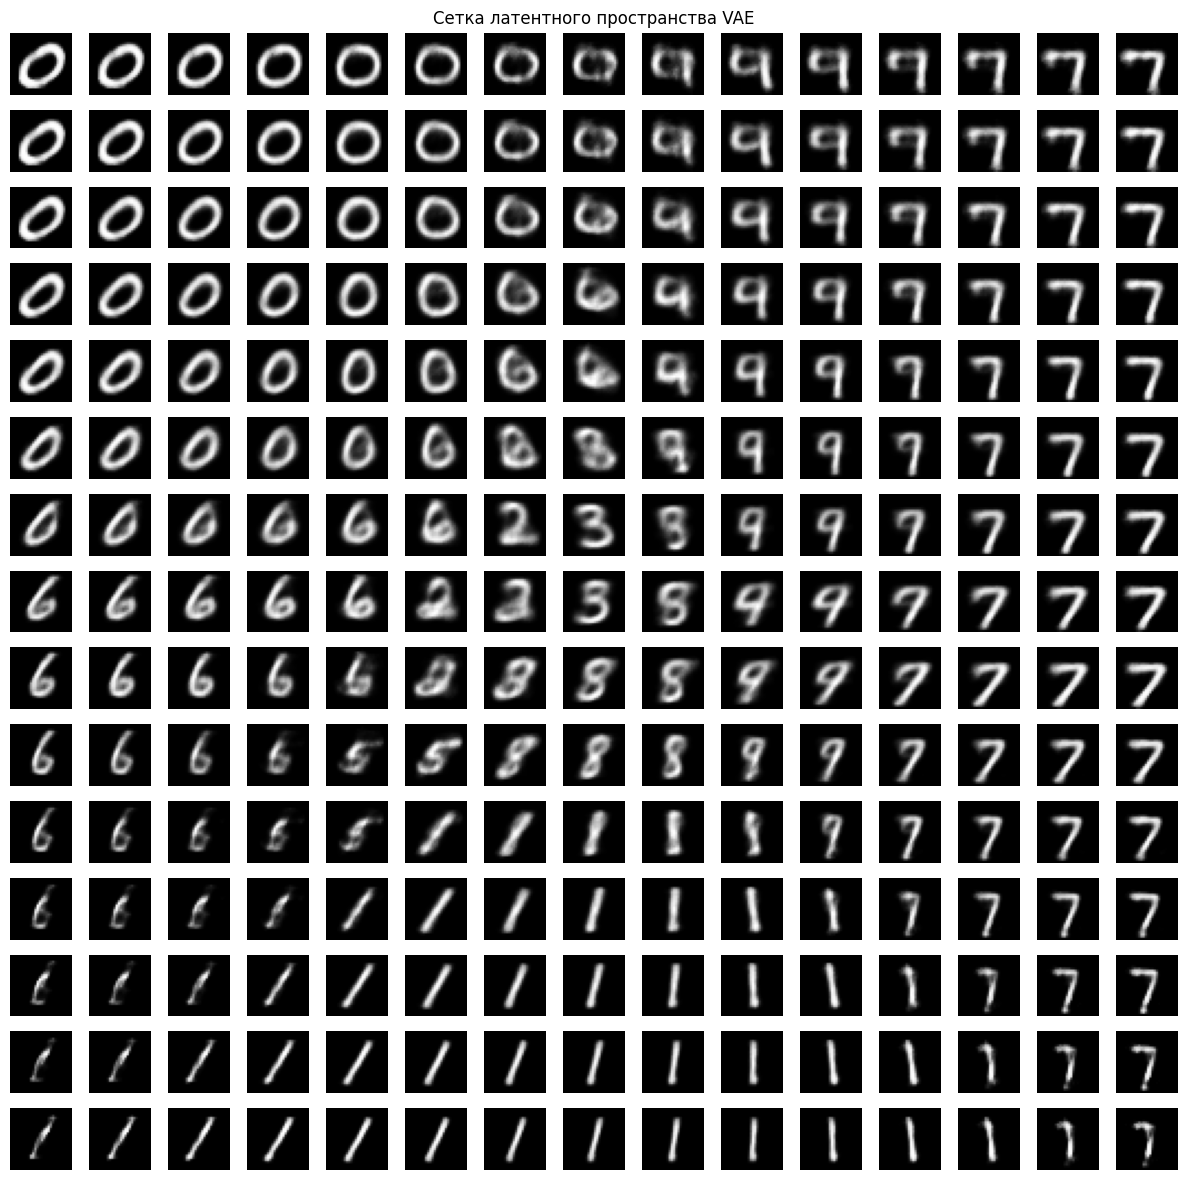

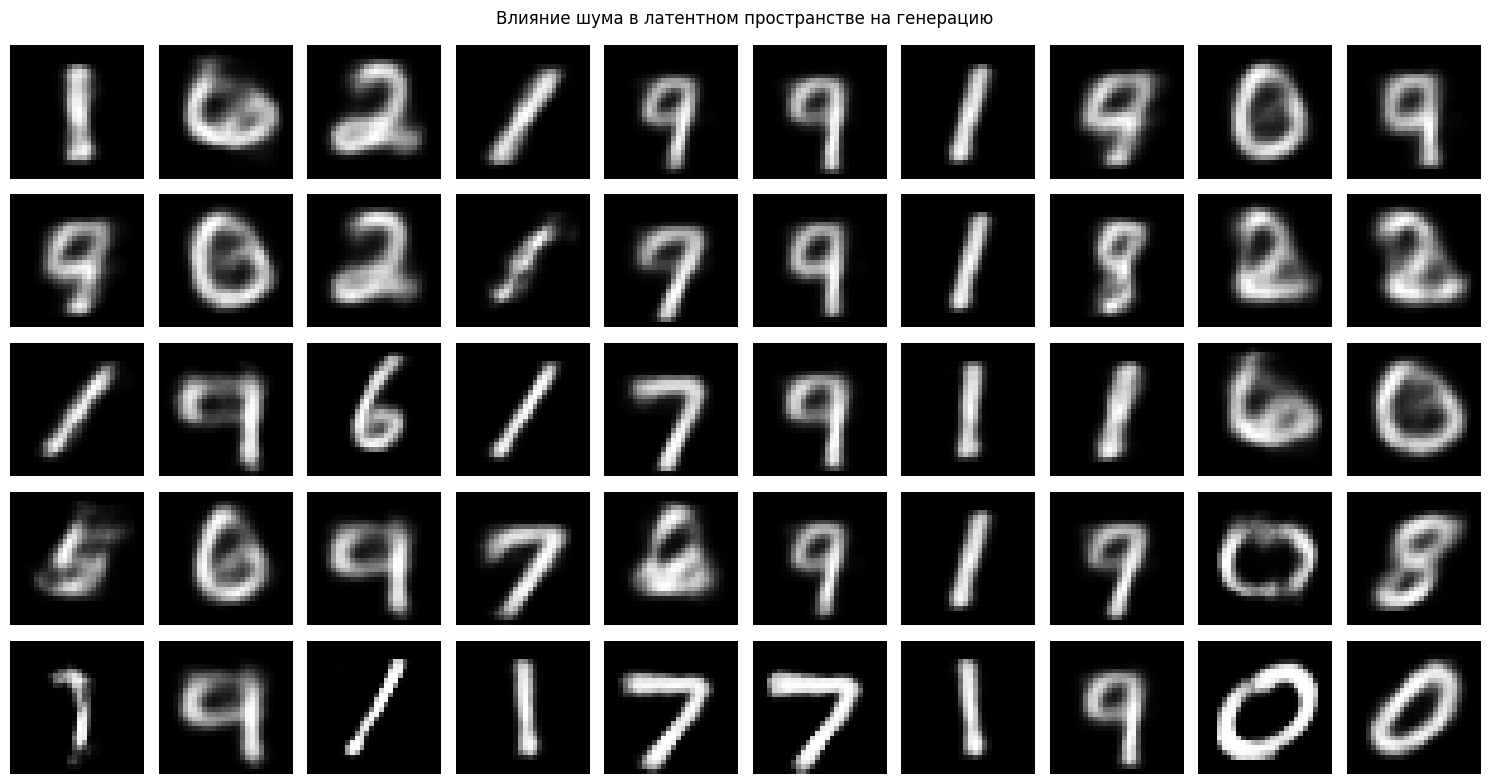


Исследование влияния размерности латентного пространства

Тестирование размерности: 2


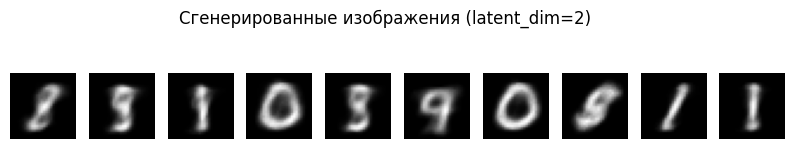


Тестирование размерности: 8


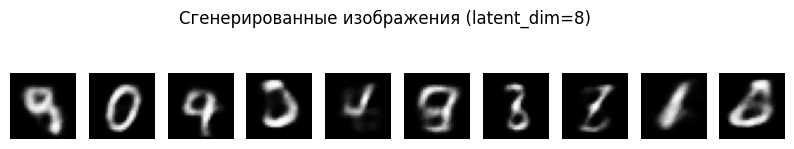


Тестирование размерности: 16


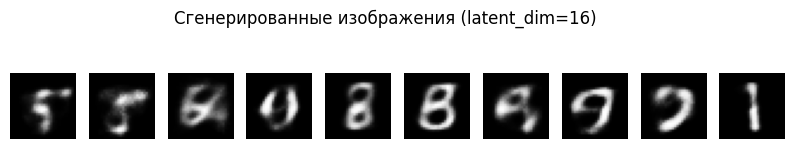


Тестирование размерности: 32


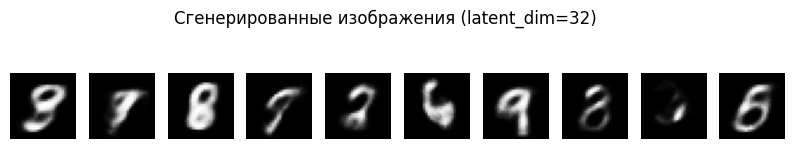

РЕКОМЕНДАЦИИ ПО ВЫБОРУ РАЗМЕРНОСТИ:
• latent_dim=2: Хорошо для визуализации, но есть ограничения
• latent_dim=8: Хороший баланс между качеством и размерностью
• latent_dim=16: Лучшее качество, но сложнее визуализировать
• latent_dim=32: Высокое качество, но больше параметров и риск переобучения


In [16]:
print("Генерация данных с помощью VAE")


latent_samples = np.random.normal(size=(10, latent_dim))
generated_images = decoder.predict(latent_samples, verbose=0)

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Сгенерированные изображения из случайных точек латентного пространства")
plt.show()


plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Оригинал', fontsize=12)
    
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Генерация VAE', fontsize=12)
plt.suptitle("Сравнение оригиналов и сгенерированных изображений VAE")
plt.tight_layout()
plt.show()


point_a = np.random.normal(size=(1, latent_dim))
point_b = np.random.normal(size=(1, latent_dim))

interpolation_steps = 10
interpolated_points = np.array([point_a + (point_b - point_a) * t for t in np.linspace(0, 1, interpolation_steps)])
interpolated_points = interpolated_points.reshape(interpolation_steps, latent_dim)
interpolated_images = decoder.predict(interpolated_points, verbose=0)

plt.figure(figsize=(15, 3))
for i in range(interpolation_steps):
    plt.subplot(1, interpolation_steps, i + 1)
    plt.imshow(interpolated_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Интерполяция между двумя точками латентного пространства")
plt.show()


grid_size = 15
grid_x = np.linspace(-3, 3, grid_size)
grid_y = np.linspace(-3, 3, grid_size)
latent_grid = np.array([[x, y] for y in grid_y for x in grid_x], dtype=np.float32)

grid_images = decoder.predict(latent_grid, verbose=0)

plt.figure(figsize=(12, 12))
for i in range(min(len(grid_images), grid_size * grid_size)):
    plt.subplot(grid_size, grid_size, i + 1)
    plt.imshow(grid_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Сетка латентного пространства VAE")
plt.tight_layout()
plt.show()


noise_levels = [0, 0.5, 1.0, 1.5, 2.0]
latent_samples_base = np.random.normal(size=(10, latent_dim))

fig, axes = plt.subplots(len(noise_levels), 10, figsize=(15, 8))

for idx, noise_level in enumerate(noise_levels):
    noisy_points = latent_samples_base + np.random.normal(scale=noise_level, size=latent_samples_base.shape)
    noisy_images = decoder.predict(noisy_points, verbose=0)
    
    for i in range(10):
        axes[idx, i].imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        axes[idx, i].axis('off')
    
    axes[idx, 0].set_ylabel(f'Шум={noise_level}', fontsize=10, rotation=90)

plt.suptitle("Влияние шума в латентном пространстве на генерацию")
plt.tight_layout()
plt.show()


print("\n" + "="*30)
print("Исследование влияния размерности латентного пространства")
print("="*30)

latent_dim_options = [2, 8, 16, 32]


class VAELossLayer(Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)
        
    def call(self, inputs):
        input_img, output, z_mean, z_log_var = inputs
        reconstruction_loss = K.sum(K.binary_crossentropy(
            K.flatten(input_img), K.flatten(output)
        ))
        kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var))
        self.add_loss(reconstruction_loss + kl_loss)
        return output

for latent_dim_test in latent_dim_options:
    print(f"\nТестирование размерности: {latent_dim_test}")
    

    input_img_new = Input(shape=(28, 28, 1))
    x = Flatten()(input_img_new)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    z_mean_new = Dense(latent_dim_test)(x)
    z_log_var_new = Dense(latent_dim_test)(x)
    

    z_new = Lambda(sampling)([z_mean_new, z_log_var_new])
    

    decoder_input_new = Input(shape=(latent_dim_test,))
    decoder_h_new = Dense(128, activation='relu')(decoder_input_new)
    decoder_h_new = Dense(256, activation='relu')(decoder_h_new)
    decoder_output_new = Dense(28 * 28, activation='sigmoid')(decoder_h_new)
    decoder_output_new = Reshape((28, 28, 1))(decoder_output_new)
    decoder_new = Model(decoder_input_new, decoder_output_new, name='decoder')
    
    output_new = decoder_new(z_new)
    

    vae_output_new = VAELossLayer()([input_img_new, output_new, z_mean_new, z_log_var_new])
    vae_new = Model(input_img_new, vae_output_new)
    vae_new.compile(optimizer='adam')
    

    vae_new.fit(x_train, epochs=5, batch_size=256, validation_split=0.1, verbose=0)
    

    latent_samples_new = np.random.normal(size=(10, latent_dim_test))
    generated_new = decoder_new.predict(latent_samples_new, verbose=0)
    

    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(generated_new[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Сгенерированные изображения (latent_dim={latent_dim_test})")
    plt.show()


print("РЕКОМЕНДАЦИИ ПО ВЫБОРУ РАЗМЕРНОСТИ:")

print("• latent_dim=2: Хорошо для визуализации, но есть ограничения")
print("• latent_dim=8: Хороший баланс между качеством и размерностью")
print("• latent_dim=16: Лучшее качество, но сложнее визуализировать")
print("• latent_dim=32: Высокое качество, но больше параметров и риск переобучения")

## Шаг 6 (Optional): Сравнение VAE и GAN

Сравнение VAE и GAN
Обучение GAN...
Эпоха    0: D loss: 0.9582, G loss: 0.5368
Эпоха  200: D loss: 0.0432, G loss: 9.7612
Эпоха  400: D loss: 0.0761, G loss: 17.4051
Эпоха  600: D loss: 0.0616, G loss: 16.1258
Эпоха  800: D loss: 0.0588, G loss: 13.2390
Эпоха 1000: D loss: 0.0558, G loss: 11.7598
Эпоха 1200: D loss: 0.0530, G loss: 10.8169
Эпоха 1400: D loss: 0.0507, G loss: 10.1913
Эпоха 1600: D loss: 0.0506, G loss: 9.7395
Эпоха 1800: D loss: 0.0533, G loss: 9.3196


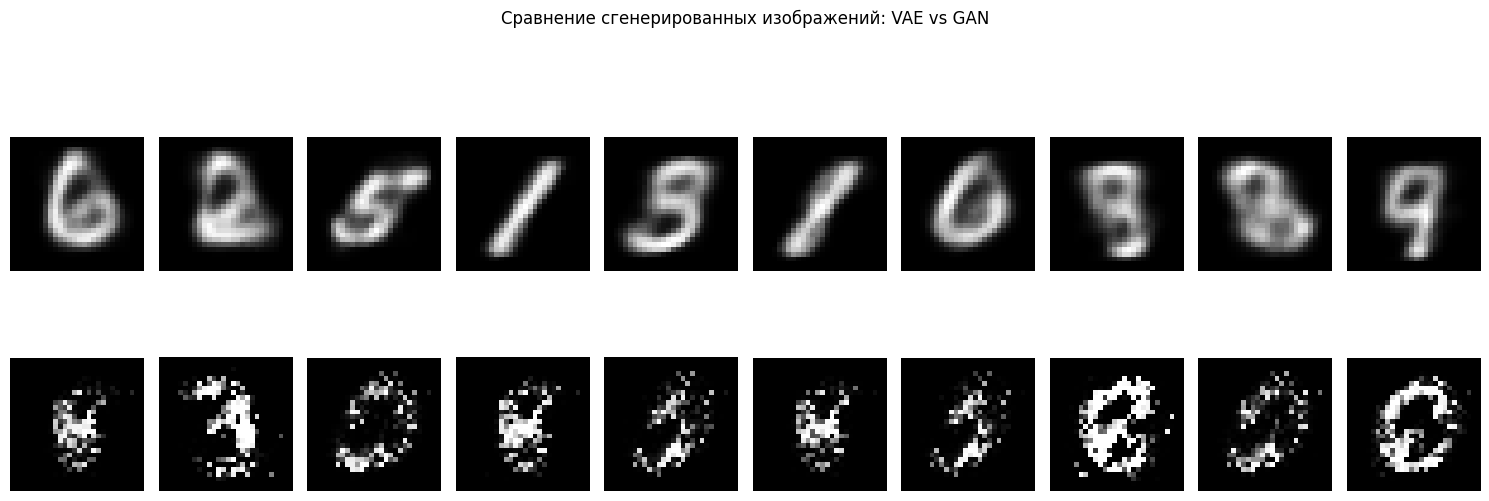

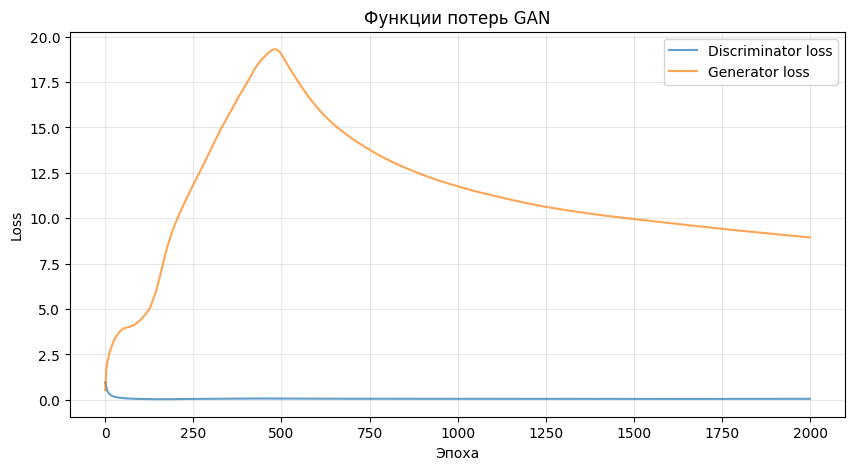

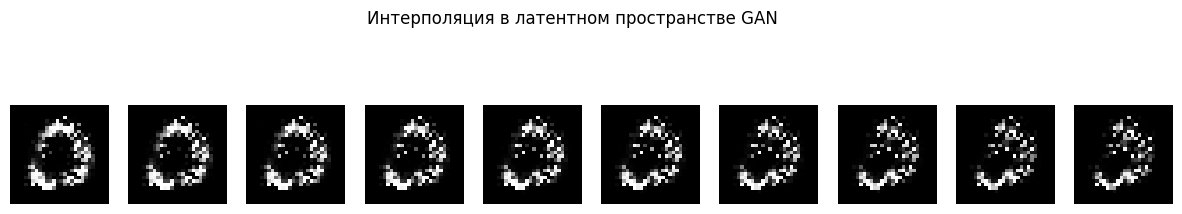

In [21]:

print("Сравнение VAE и GAN")


from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU, BatchNormalization, Input, Dropout
from tensorflow.keras.optimizers import Adam


latent_dim_gan = 100
batch_size_gan = 64
epochs_gan = 2000

# Генератор
def build_generator(latent_dim):
    model = Sequential([
        Dense(256, input_dim=latent_dim),
        LeakyReLU(alpha=0.2),
        BatchNormalization(),
        Dense(512),
        LeakyReLU(alpha=0.2),
        BatchNormalization(),
        Dense(1024),
        LeakyReLU(alpha=0.2),
        BatchNormalization(),
        Dense(28 * 28, activation='sigmoid'),
        Reshape((28, 28, 1))
    ])
    return model


def build_discriminator():
    model = Sequential([
        Flatten(input_shape=(28, 28, 1)),
        Dense(512),
        LeakyReLU(alpha=0.2),
        Dropout(0.3),
        Dense(256),
        LeakyReLU(alpha=0.2),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model


generator_gan = build_generator(latent_dim_gan)
discriminator = build_discriminator()
discriminator.compile(optimizer=Adam(learning_rate=0.0002, beta_1=0.5), 
                      loss='binary_crossentropy', 
                      metrics=['accuracy'])

discriminator.trainable = False
gan_input = Input(shape=(latent_dim_gan,))
gan_output = discriminator(generator_gan(gan_input))
gan = Model(gan_input, gan_output)
gan.compile(optimizer=Adam(learning_rate=0.0002, beta_1=0.5), loss='binary_crossentropy')


d_losses = []
g_losses = []

print("Обучение GAN...")
for epoch in range(epochs_gan):

    noise = np.random.normal(0, 1, (batch_size_gan, latent_dim_gan))
    generated_images_gan = generator_gan.predict(noise, verbose=0)
    
    idx = np.random.randint(0, x_train.shape[0], batch_size_gan)
    real_images = x_train[idx]
    
    real_labels = np.ones((batch_size_gan, 1))
    fake_labels = np.zeros((batch_size_gan, 1))
    
    discriminator.trainable = True
    d_loss_real = discriminator.train_on_batch(real_images, real_labels)
    d_loss_fake = discriminator.train_on_batch(generated_images_gan, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    

    noise = np.random.normal(0, 1, (batch_size_gan, latent_dim_gan))
    misleading_labels = np.ones((batch_size_gan, 1))
    discriminator.trainable = False
    g_loss = gan.train_on_batch(noise, misleading_labels)
    
    d_losses.append(d_loss[0])
    g_losses.append(g_loss)
    
    if epoch % 200 == 0:
        print(f"Эпоха {epoch:4d}: D loss: {d_loss[0]:.4f}, G loss: {g_loss:.4f}")


noise = np.random.normal(0, 1, (10, latent_dim_gan))
generated_gan = generator_gan.predict(noise, verbose=0)


plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('VAE', fontsize=12)
    
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(generated_gan[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('GAN', fontsize=12)
plt.suptitle("Сравнение сгенерированных изображений: VAE vs GAN")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator loss', alpha=0.7)
plt.plot(g_losses, label='Generator loss', alpha=0.7)
plt.title('Функции потерь GAN')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


point_a_gan = np.random.normal(0, 1, (1, latent_dim_gan))
point_b_gan = np.random.normal(0, 1, (1, latent_dim_gan))

interp_steps_gan = 10
interp_points_gan = np.array([point_a_gan + (point_b_gan - point_a_gan) * t for t in np.linspace(0, 1, interp_steps_gan)])
interp_points_gan = interp_points_gan.reshape(interp_steps_gan, latent_dim_gan)
interp_images_gan = generator_gan.predict(interp_points_gan, verbose=0)

plt.figure(figsize=(15, 3))
for i in range(interp_steps_gan):
    plt.subplot(1, interp_steps_gan, i + 1)
    plt.imshow(interp_images_gan[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Интерполяция в латентном пространстве GAN")
plt.show()

Видим что GAN отработал очень плохо, но оставим полученный результат для сравнения

## Шаг 7: Анализ результатов

Анализ результатов


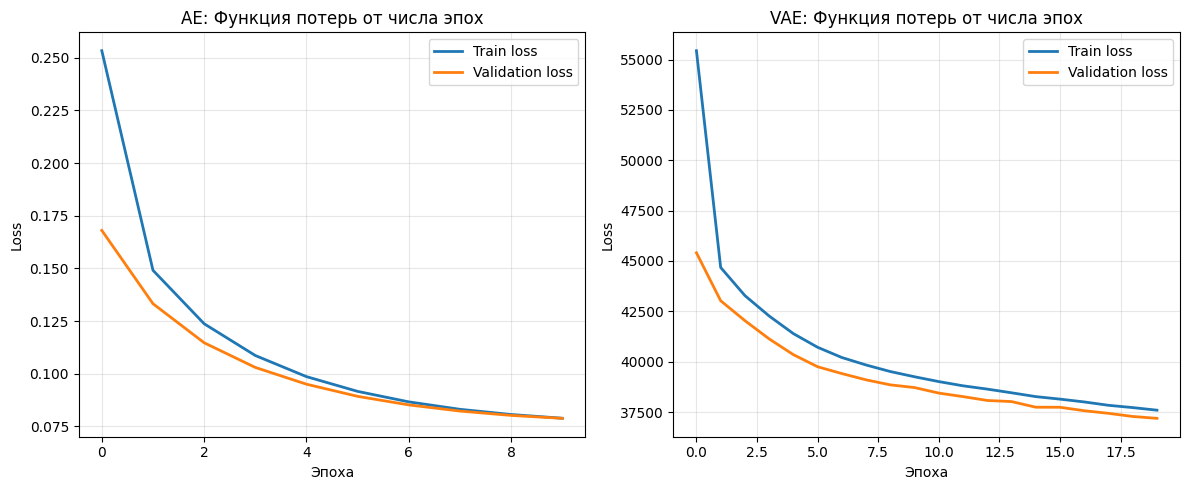

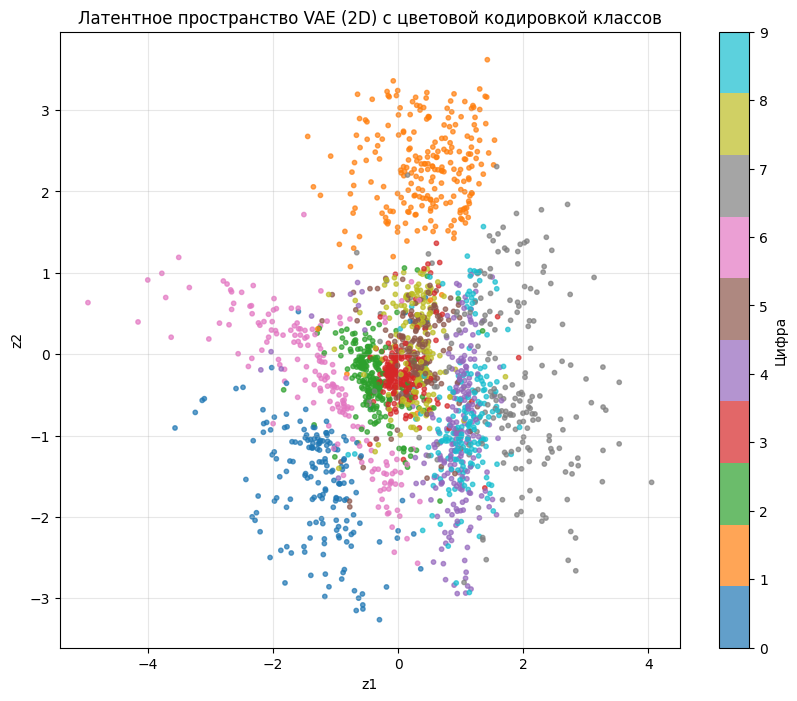


Сравнение MSE (Mean Squared Error):
PCA: 0.009047
AE:  0.005117
VAE: 0.040187


In [23]:
print("Анализ результатов")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_ae.history['loss'], label='Train loss', linewidth=2)
plt.plot(history_ae.history['val_loss'], label='Validation loss', linewidth=2)
plt.title('AE: Функция потерь от числа эпох')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_vae.history['loss'], label='Train loss', linewidth=2)
if 'val_loss' in history_vae.history:
    plt.plot(history_vae.history['val_loss'], label='Validation loss', linewidth=2)
plt.title('VAE: Функция потерь от числа эпох')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

encoder_model = Model(input_img, z_mean)
z_points_all = encoder_model.predict(x_test[:2000], verbose=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_points_all[:, 0], z_points_all[:, 1], 
                     c=y_test[:2000], cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, label='Цифра')
plt.title("Латентное пространство VAE (2D) с цветовой кодировкой классов")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True, alpha=0.3)
plt.show()

from sklearn.metrics import mean_squared_error

x_test_reconstructed_ae = autoencoder.predict(x_test, verbose=0)
x_test_reconstructed_vae = vae.predict(x_test, verbose=0)

mse_ae_final = mean_squared_error(x_test.flatten(), x_test_reconstructed_ae.flatten())
mse_vae_final = mean_squared_error(x_test.flatten(), x_test_reconstructed_vae.flatten())
mse_pca_final = mean_squared_error(x_test_flat, x_test_reconstructed_pca)

print("\n" + "="*50)
print("Сравнение MSE (Mean Squared Error):")
print("="*50)
print(f"PCA: {mse_pca_final:.6f}")
print(f"AE:  {mse_ae_final:.6f}")
print(f"VAE: {mse_vae_final:.6f}")

В ходе выполнения лабораторной работы были реализованы и проанализированы три метода уменьшения размерности и генерации данных для датасета MNIST: PCA, классический автокодировщик (AE) и вариационный автокодировщик (VAE), а также проведено сравнение с генеративно-состязательной сетью (GAN). Оценка качества реконструкции по метрике MSE показала, что наилучший результат демонстрирует AE (0.005117), за ним следует PCA (0.009047), а VAE ожидаемо показал более высокую ошибку (0.040187) из-за регуляризации KL-дивергенцией, которая обеспечивает непрерывность латентного пространства. При генерации новых данных VAE успешно создавал разнообразные изображения рукописных цифр, позволяя выполнять плавную интерполяцию между точками латентного пространства и исследовать влияние размерности (оптимальной оказалась размерность 8-16). GAN, обученный в течение 2000 эпох, столкнулся с типичной проблемой нестабильности: дискриминатор быстро стал доминировать (D loss упал до 0.05), а генератор не смог развиться (G loss вырос до значений 9-17), что привело к генерации неразборчивых изображений. Таким образом, VAE показал себя как более стабильный и предсказуемый метод для генерации данных и анализа латентного пространства, в то время как GAN требует значительно более тщательной настройки гиперпараметров и большего количества эпох для достижения приемлемых результатов.

Выполнила Гареева Д.Р. 507540